# Following splink's example, for the synthetic dataset

We follow the steps done in 

`https://moj-analytical-services.github.io/splink/demos/examples/duckdb/transactions.html`

while adapting the datasets for the synthetic dataset.

In [1]:
# Required dependencies
import pandas as pd
import numpy as np
import os
import sys
import yaml

from splink import DuckDBAPI, Linker, SettingsCreator, block_on


import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Notebook config helper, handles path config and package imports 
from notebook_helper import setup_notebook_environment
helper = setup_notebook_environment()

from em_pipeline.data_loader import (
    load_pair_dfs_from_paths,
    standardise_dt,
)
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_non_numerical_blocking_rules,
    get_non_numerical_estimating_blocking_rules,
    get_datetime_comparison,
    get_category_comparison
)

In [2]:
NOTEBOOK_NAME = "splink_local_low_card"

MEM_LIMIT  = "24GB"
TEMP_DIR   = "/tmp"

# Column names used in the synthetic dataset
LEFT_ID_COL   = "local_source_id"      # appears in both df1 & df2 after loading
RIGHT_ID_COL  = "local_source_id"
UNIQUE_ID_COL = "row_id"                # we eventually attempt to build this for labelling.
GROUND_TRUTH_ID_COL = "latent_event_id"      # used for ground truths
CATEGORICAL_COL   = "categorical"
NUMERIC_COL       = "numerical_noisy"
DATETIME_COL      = "datetime_noisy"

# How strict we want the initial random‑match estimate to be
RECALL_FOR_PRIOR = 0.99   # same as the original notebook

In [3]:
dataset_a_path, dataset_b_path = helper.ensure_dataset_exists('low_card')

print(f"Dataset A path: {dataset_a_path}")
print(f"Dataset B path: {dataset_b_path}")


Dataset A path: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/../data/low_card_dataset_a.parquet
Dataset B path: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/../data/low_card_dataset_b.parquet


In [4]:
df1, df2 = load_pair_dfs_from_paths(dataset_a_path, dataset_b_path)

print(f"\nDataset A shape: {df1.shape}")
print(f"Dataset B shape: {df2.shape}")

print(f"\nDataset A columns: {list(df1.columns)}")
print(f"Dataset B columns: {list(df2.columns)}")


Dataset A shape: (1767, 5)
Dataset B shape: (1304, 5)

Dataset A columns: ['global_entity_id', 'local_source_id', 'categorical', 'datetime_noisy', 'latent_event_id']
Dataset B columns: ['global_entity_id', 'local_source_id', 'categorical', 'datetime_noisy', 'latent_event_id']


In [5]:
df1["row_id"] = "df1_" + df1.index.astype(str)
df2["row_id"] = "df2_" + df2.index.astype(str)
df1

,global_entity_id,local_source_id,categorical,datetime_noisy,latent_event_id,row_id
0,100050,DF1_100050,CAT_0,2025-12-31 04:17:52.577959294,OVER_0,df1_0
1,100173,DF1_100173,CAT_0,2025-12-31 08:38:21.657414024,UNI_A_344,df1_1
2,100025,DF1_100025,CAT_0,2025-12-31 13:15:36.761647501,OVER_1,df1_2
3,100088,DF1_100088,CAT_1,2025-12-31 16:17:15.675938055,UNI_A_345,df1_3
4,100025,DF1_100025,CAT_0,2025-12-31 19:16:52.280188259,OVER_2,df1_4
...,...,...,...,...,...,...
1762,100178,DF1_100178,CAT_1,2026-02-28 22:44:36.068532525,OVER_338,df1_1762
1763,100007,DF1_100007,CAT_0,2026-02-28 23:51:41.286678350,OVER_342,df1_1763
1764,100132,DF1_100132,CAT_1,2026-03-01 04:14:21.782313228,UNI_A_1764,df1_1764
1765,100072,DF1_100072,CAT_0,2026-03-01 04:43:33.555446559,UNI_A_1765,df1_1765


### Basic EDA, processing

In [6]:
# Basic preprocessing - we currently assume we do not have consistency in time across both DFs. 
# If this is no longer the case, just remove this line and update the datetime comparisons/blocking accordingly.
standardise_dt(df1, df2, DATETIME_COL)

Set datetime_noisy to date for both df1 and df2.


In [7]:
df2

,global_entity_id,local_source_id,categorical,datetime_noisy,latent_event_id,row_id
0,100050,DF1_100050,CAT_0,2025-12-31,OVER_0,df2_0
1,100025,DF1_100025,CAT_0,2025-12-31,OVER_1,df2_1
2,100035,DF2_100035,CAT_1,2025-12-31,UNIQ_B_1767,df2_2
3,100059,DF2_100059,CAT_1,2025-12-31,UNIQ_B_1768,df2_3
4,100109,DF2_100109,CAT_1,2025-12-31,UNIQ_B_1769,df2_4
...,...,...,...,...,...,...
1299,100050,DF1_100050,CAT_0,2026-02-28,OVER_339,df2_1299
1300,100151,DF1_100151,CAT_1,2026-02-28,OVER_340,df2_1300
1301,100044,DF2_100044,CAT_0,2026-03-01,UNIQ_B_2726,df2_1301
1302,100151,DF1_100151,CAT_1,2026-03-01,OVER_341,df2_1302


### We can take a look at the distributions of the data with profile_columns

In [8]:
from splink.exploratory import profile_columns

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

profile_columns(
    [df1, df2],
    db_api=db_api,
    column_expressions=[
        "categorical",
        "datetime_noisy",
    ],
)

alt.VConcatChart(...)

### Splink's blocking analysis tool

We can use this to take a look at how effective our blocking is. Each increment introduces more unique pairs (w.r.t. previous blocking rules) into the total - the approach here is to get rid of pairs that we KNOW cannot be matches.

In [9]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)

brs = get_non_numerical_blocking_rules()

cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1, df2],
    blocking_rules=brs,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name=UNIQUE_ID_COL
)

alt.Chart(...)

We've dropped the number of comparisons from somewhere north of 12 million pairs to roughly 8 million - a 30%+ reduction. Given we have better heuristics about pairs that are definitely not matches, we can further reduce this.

### Pulling comparisons, setting up splink for estimation

In [10]:
# We use the preset comparison levels for the artificial dataset, these can be found and tweaked at em_pipeline/comparisons.py
datetime_noisy_comparison = get_datetime_comparison(dt_col=DATETIME_COL)
categorical_comparison = get_category_comparison(cat_col=CATEGORICAL_COL)

In [11]:
settings = SettingsCreator(
    link_type="link_only", 
    unique_id_column_name=UNIQUE_ID_COL,
    blocking_rules_to_generate_predictions=brs,
    max_iterations=50,
    comparisons=[
        categorical_comparison,
        datetime_noisy_comparison,
    ],
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["local_source_id", "latent_event_id"],
)

linker = Linker(
    [df1, df2],
    settings,
    db_api=db_api
)

In [12]:
# "training" the linker - we first estimate an overall prior pi - basically the likelihood of a match.
# we do this by estimating it with a set of strict blockers that we know MUST be matches.

linker.training.estimate_probability_two_random_records_match(
    get_non_numerical_estimating_blocking_rules(), recall=0.9
)

Probability two random records match is estimated to be  0.0082.
This means that amongst all possible pairwise record comparisons, one in 121.96 are expected to match.  With 2,304,168 total possible comparisons, we expect a total of around 18,893.33 matching pairs


In [13]:
# Making estimates for u values.

linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - categorical (no m values are trained).
    - datetime_noisy (no m values are trained).


In [14]:
# We now estimate m values, we do this with a two-pass fixing one column and estimating for all columns BUT that one.
# In this case, we care about just a basic, loose set of blockers so that our EM has enough pairs to make estimations
# for various bins.

# Pass 1 - estimate parameters blocking on date.
linker.training.estimate_parameters_using_expectation_maximisation(
     """
        ABS(
            epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
            epoch(CAST(r.datetime_noisy AS TIMESTAMP))
        ) <= 172800
    """
)

# Pass 2 - estimate parameters blocking on categorical
linker.training.estimate_parameters_using_expectation_maximisation(
    """
    l.categorical = r.categorical
    """
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        ABS(
            epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
            epoch(CAST(r.datetime_noisy AS TIMESTAMP))
        ) <= 172800
    

Parameter estimates will be made for the following comparison(s):
    - categorical

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - datetime_noisy

Iteration 1: Largest change in params was 0.000718 in the m_probability of categorical, level `All other comparisons`
Iteration 2: Largest change in params was -0.000722 in the m_probability of categorical, level `Exact match on categorical`
Iteration 3: Largest change in params was -0.000726 in the m_probability of categorical, level `Exact match on categorical`
Iteration 4: Largest change in params was 0.000731 in the m_probability of categorical, level `All other comparisons`
Iteration 5: Largest change in params was 

<EMTrainingSession, blocking on 
    l.categorical = r.categorical
    , deactivating comparisons categorical>

In [15]:
# We can view the estimated match weights

linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

### Predict, and analysis

In [16]:
df_predict = linker.inference.predict()
pd_predict = df_predict.as_pandas_dataframe()

Blocking time: 0.70 seconds
Predict time: 0.43 seconds


In [17]:
pd_predict

,match_weight,match_probability,source_dataset_l,source_dataset_r,row_id_l,row_id_r,categorical_l,categorical_r,gamma_categorical,bf_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,bf_datetime_noisy,local_source_id_l,local_source_id_r,latent_event_id_l,latent_event_id_r,match_key
0,-4.992022,0.030466,__splink__input_table_0,__splink__input_table_1,df1_644,df2_485,CAT_0,CAT_0,1,1.819123,2026-01-20,2026-01-23,1,2.089390,DF1_100072,DF1_100051,UNI_A_861,OVER_135,0
1,-4.992022,0.030466,__splink__input_table_0,__splink__input_table_1,df1_646,df2_530,CAT_1,CAT_1,1,1.819123,2026-01-20,2026-01-24,1,2.089390,DF1_100025,DF2_100141,OVER_126,UNIQ_B_2148,0
2,-4.992022,0.030466,__splink__input_table_0,__splink__input_table_1,df1_647,df2_485,CAT_0,CAT_0,1,1.819123,2026-01-20,2026-01-23,1,2.089390,DF1_100159,DF1_100051,UNI_A_862,OVER_135,0
3,-4.992022,0.030466,__splink__input_table_0,__splink__input_table_1,df1_648,df2_530,CAT_1,CAT_1,1,1.819123,2026-01-20,2026-01-24,1,2.089390,DF1_100075,DF2_100141,UNI_A_863,UNIQ_B_2148,0
4,-4.992022,0.030466,__splink__input_table_0,__splink__input_table_1,df1_649,df2_485,CAT_0,CAT_0,1,1.819123,2026-01-20,2026-01-23,1,2.089390,DF1_100151,DF1_100051,OVER_130,OVER_135,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681028,-11.074515,0.000463,__splink__input_table_0,__splink__input_table_1,df1_537,df2_38,CAT_1,CAT_0,0,0.181137,2026-01-17,2026-01-02,0,0.309643,DF1_100133,DF2_100061,UNI_A_773,UNIQ_B_1793,1
1681029,-11.074515,0.000463,__splink__input_table_0,__splink__input_table_1,df1_539,df2_38,CAT_1,CAT_0,0,0.181137,2026-01-17,2026-01-02,0,0.309643,DF1_100133,DF2_100061,UNI_A_775,UNIQ_B_1793,1
1681030,-11.074515,0.000463,__splink__input_table_0,__splink__input_table_1,df1_540,df2_38,CAT_1,CAT_0,0,0.181137,2026-01-17,2026-01-02,0,0.309643,DF1_100062,DF2_100061,UNI_A_776,UNIQ_B_1793,1
1681031,-8.609667,0.002553,__splink__input_table_0,__splink__input_table_1,df1_541,df2_38,None,CAT_0,-1,1.000000,2026-01-17,2026-01-02,0,0.309643,DF1_100126,DF2_100061,UNI_A_777,UNIQ_B_1793,1


In [18]:
# 2. Flag true matches inside the scored pool
pd_predict["is_true_match"] = (
    pd_predict["latent_event_id_l"] == pd_predict["latent_event_id_r"]
).astype(int)

# 3. Get the total true match ceiling via a fast 1-to-1 merge count
# This catches matches that were blocked, ensuring Recall remains accurate
total_true_matches = (
    df1[["latent_event_id"]]
    .merge(df2[["latent_event_id"]], on="latent_event_id")
    .shape[0]
)

# 4. Generate metrics across thresholds (0.0 to 1.0)
thresholds = np.linspace(0.0, 1.0, 101)
curve_data = []

for t in thresholds:
    # Filter predictions at current probability threshold
    pred_positive = pd_predict["match_probability"] >= t

    tp = ((pred_positive) & (pd_predict["is_true_match"] == 1)).sum()
    fp = ((pred_positive) & (pd_predict["is_true_match"] == 0)).sum()

    # Calculate metrics with standard division-by-zero safeguards
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / total_true_matches if total_true_matches > 0 else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    curve_data.append(
        {"threshold": t, "precision": precision, "recall": recall, "f1_score": f1}
    )

df_curve = pd.DataFrame(curve_data)

print("--- CORE PERFORMANCE THRESHOLDS ---")
print(df_curve.head(20))


--- CORE PERFORMANCE THRESHOLDS ---
    threshold  precision    recall  f1_score
0        0.00   0.000205  1.000000  0.000409
1        0.01   0.001397  1.000000  0.002790
2        0.02   0.001628  1.000000  0.003251
3        0.03   0.001771  1.000000  0.003536
4        0.04   0.005314  1.000000  0.010571
5        0.05   0.005989  0.962209  0.011903
6        0.06   0.005989  0.962209  0.011903
7        0.07   0.005989  0.962209  0.011903
8        0.08   0.011596  0.735465  0.022833
9        0.09   0.011596  0.735465  0.022833
10       0.10   0.011596  0.735465  0.022833
11       0.11   0.011596  0.735465  0.022833
12       0.12   0.011596  0.735465  0.022833
13       0.13   0.012409  0.613372  0.024326
14       0.14   0.012409  0.613372  0.024326
15       0.15   0.012409  0.613372  0.024326
16       0.16   0.012409  0.613372  0.024326
17       0.17   0.012409  0.613372  0.024326
18       0.18   0.012409  0.613372  0.024326
19       0.19   0.012409  0.613372  0.024326


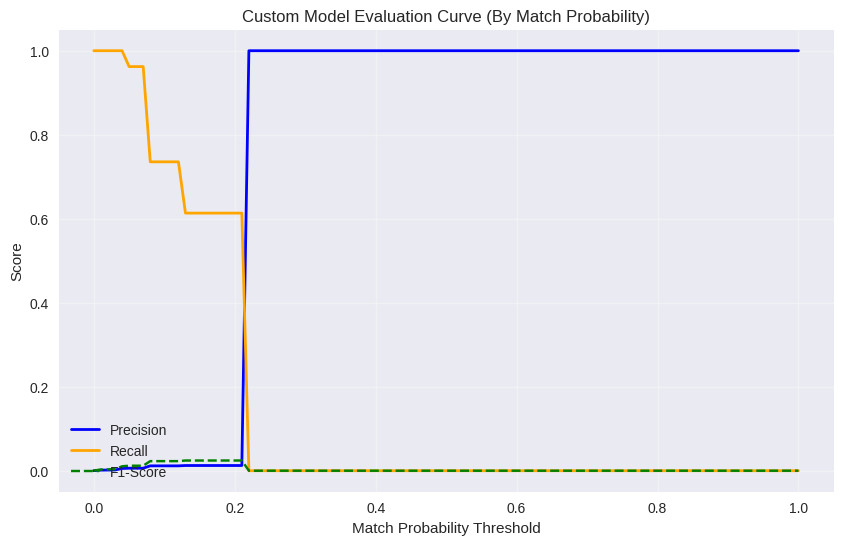

In [19]:
from notebook_helper import save_chart

plt.figure(figsize=(10, 6))
plt.plot(df_curve["threshold"], df_curve["precision"], label="Precision", color="blue", lw=2)
plt.plot(df_curve["threshold"], df_curve["recall"], label="Recall", color="orange", lw=2)
plt.plot(df_curve["threshold"], df_curve["f1_score"], label="F1-Score", color="green", linestyle="--")

plt.title("Custom Model Evaluation Curve (By Match Probability)")
plt.xlabel("Match Probability Threshold")
plt.ylabel("Score")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# Save it using our helper:
save_chart(plt.gcf(), NOTEBOOK_NAME, "threshold_curve")
plt.show()
plt.close()

### Reviewing our results

In [20]:
linker.evaluation.accuracy_analysis_from_labels_column(
    GROUND_TRUTH_ID_COL, 
    output_type="threshold_selection",
    add_metrics=["f1", "accuracy"]
)

Blocking time: 0.68 seconds
Predict time: 0.42 seconds


alt.HConcatChart(...)

In [21]:
linker.evaluation.unlinkables_chart()

alt.LayerChart(...)

In [22]:
from notebook_helper import get_savable_visualisations, save_threshold_curve

viz = get_savable_visualisations(NOTEBOOK_NAME, linker)
viz.match_weights_chart().save_image("match_weights_chart")
viz.unlinkables_chart().save_image("unlinkables_chart")

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


'/home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_low_card/unlinkables_chart.png'

## We see that local matches are rather poor - due to the lack of discriminatory factors (low cardinality)

In [23]:
from notebook_helper import (
    aggregate_entity_pair_matched_pairs,
    compute_source_sizes,
    calculate_match_density,
    calculate_weighted_jaccard,
    calculate_weighted_overlap,
    calculate_score_prob_ratio,
    second_layer_splink_evaluation,
    save_score_distribution_plot,
    save_precision_recall_curve,
    get_savable_visualisations
)

U_BASE = linker._settings_obj._probability_two_random_records_match

aggregated_df = aggregate_entity_pair_matched_pairs(
    pd_predict,
    id_columns=['local_source_id_l', 'local_source_id_r']
)

print("Aggregated entity-pair DataFrame shape:", aggregated_df.shape)
print("\nColumns:", list(aggregated_df.columns))
print("\nFirst 5 rows:")
display(aggregated_df.head())

Aggregated entity-pair DataFrame shape: (10000, 8)

Columns: ['local_source_id_l', 'local_source_id_r', 'sum_p', 'max_w', 'observed_edges', 'top_3_mean_w', 'score_noisy_or', 'score_softmax_p']

First 5 rows:


/home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/helpers/entity_resolution_aggregation.py:247: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(apply_agg_functions)


,local_source_id_l,local_source_id_r,sum_p,max_w,observed_edges,top_3_mean_w,score_noisy_or,score_softmax_p
0,DF1_100000,DF1_100007,0.908990,-1.883754,100,-3.513597,0.611008,0.009677
1,DF1_100000,DF1_100020,0.773497,-2.746997,59,-3.359008,0.547868,0.013603
2,DF1_100000,DF1_100025,0.264131,-4.992022,55,-5.279770,0.233360,0.004837
3,DF1_100000,DF1_100037,1.970464,-1.883754,176,-1.883754,0.873869,0.012145
4,DF1_100000,DF1_100038,1.194116,-1.883754,114,-2.459249,0.712697,0.011252


In [24]:
source_sizes = compute_source_sizes(df1, df2, 'local_source_id')

def add_structural_metrics(row):
    # Get sizes for left and right entities
    size_l = source_sizes.get(row['local_source_id_l'], {'size_l': 0})['size_l']
    size_r = source_sizes.get(row['local_source_id_r'], {'size_r': 0})['size_r']
    
    # Match density
    row['match_density'] = calculate_match_density(
        row['sum_p'], size_l, size_r
    )
    # Weighted Jaccard
    row['weighted_jaccard'] = calculate_weighted_jaccard(
        row['sum_p'], size_l, size_r
    )
    # Weighted overlap
    row['weighted_overlap'] = calculate_weighted_overlap(
        row['sum_p'], size_l, size_r
    )
    # Score-probability expected ratio (requires u_base from your Splink model)
    # You can estimate u_base as the average match probability from the prior
    # or use the m/u probabilities from the linker; here we use a placeholder.
    # Replace u_base_estimate with your actual value from the linker training.
    u_base_estimate = U_BASE  # <-- UPDATE THIS with your linker's u probability
    row['score_prob_expected_ratio'] = calculate_score_prob_ratio(
        row['sum_p'], size_l, size_r, u_base_estimate
    )
    return row

aggregated_with_metrics = aggregated_df.apply(add_structural_metrics, axis=1)

print("\nAfter adding structural metrics:")
display(aggregated_with_metrics[['local_source_id_l', 'local_source_id_r',
                               'sum_p', 'match_density', 'weighted_jaccard',
                               'weighted_overlap', 'score_noisy_or', 'score_softmax_p' ,'score_prob_expected_ratio']].head())



After adding structural metrics:


,local_source_id_l,local_source_id_r,sum_p,match_density,weighted_jaccard,weighted_overlap,score_noisy_or,score_softmax_p,score_prob_expected_ratio
0,DF1_100000,DF1_100007,0.908990,0.006184,0.033553,0.129856,0.611008,0.009677,-0.282188
1,DF1_100000,DF1_100020,0.773497,0.008500,0.040231,0.110500,0.547868,0.013603,0.035973
2,DF1_100000,DF1_100025,0.264131,0.003430,0.014892,0.037733,0.233360,0.004837,-0.871446
3,DF1_100000,DF1_100037,1.970464,0.008043,0.049225,0.281495,0.873869,0.012145,-0.019324
4,DF1_100000,DF1_100038,1.194116,0.007108,0.040063,0.170588,0.712697,0.011252,-0.142892


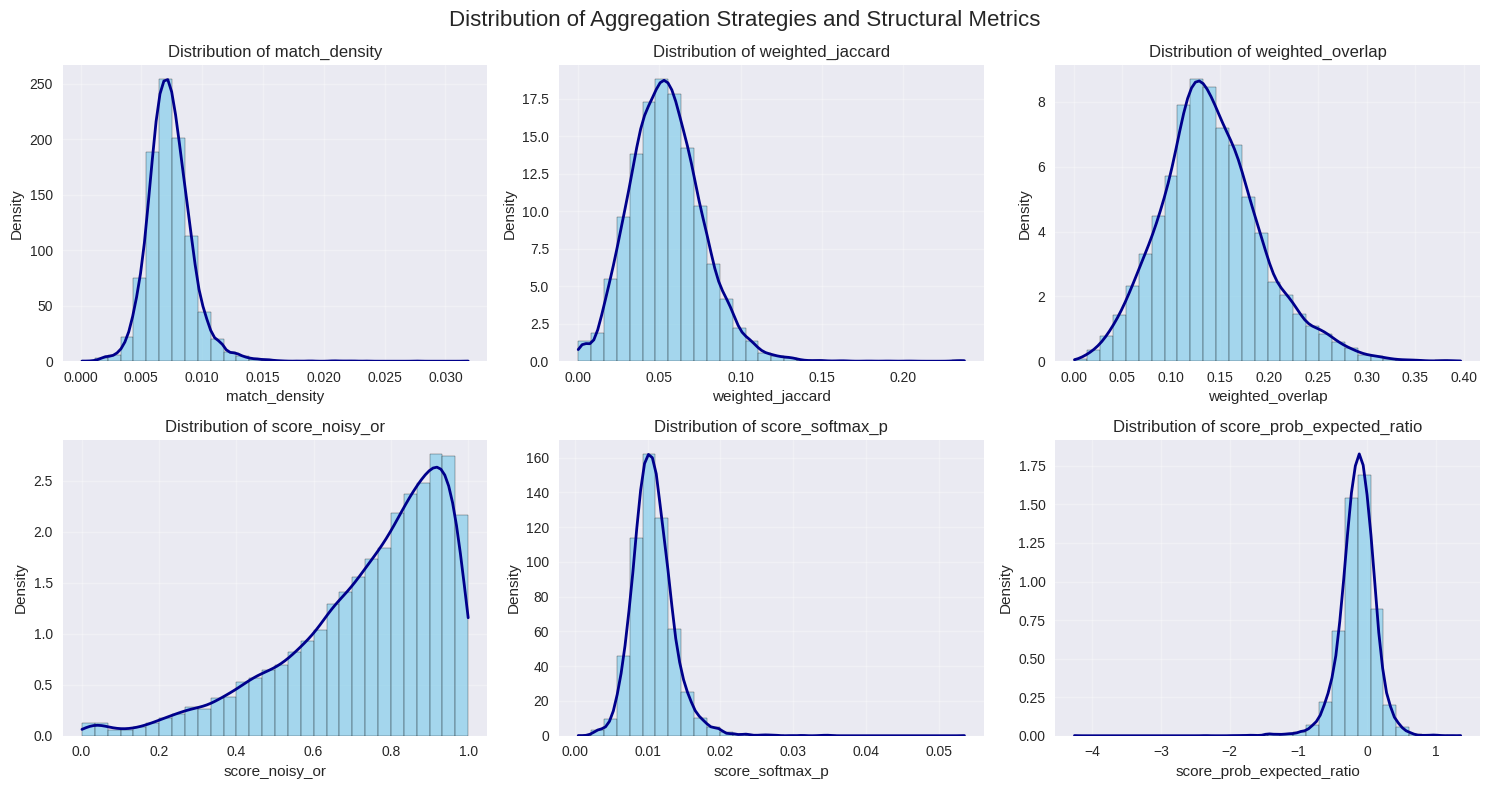

In [25]:
metrics_to_plot = [
    'match_density',
    'weighted_jaccard', 
    'weighted_overlap',
    'score_noisy_or',
    'score_softmax_p',
    'score_prob_expected_ratio'
]

# Create subplot layout
n_metrics = len(metrics_to_plot)
n_cols = min(3, n_metrics)
n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_metrics == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)

axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

# Plot each metric
for idx, col in enumerate(metrics_to_plot):
    if idx >= len(axes_flat):
        break
    ax = axes_flat[idx]
    
    # Get data and remove NaNs
    data = aggregated_with_metrics[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{col} (No Data)')
        continue
    
    # Create histogram with KDE
    ax.hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Add KDE if scipy is available
    try:
        from scipy import stats
        kde = stats.gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 100)
        ax.plot(x_range, kde(x_range), 'darkblue', linewidth=2)
    except ImportError:
        pass  # Skip KDE if scipy not available
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(metrics_to_plot), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Distribution of Aggregation Strategies and Structural Metrics', fontsize=16)
plt.tight_layout()

# In notebook: show_and_save_fig(fig, "splink_local_demo", "combined_aggregation_metrics_distribution")
plt.show()  # For script execution

Limited left entities to 50 (random sample)
Limited right entities to 50 (random sample)


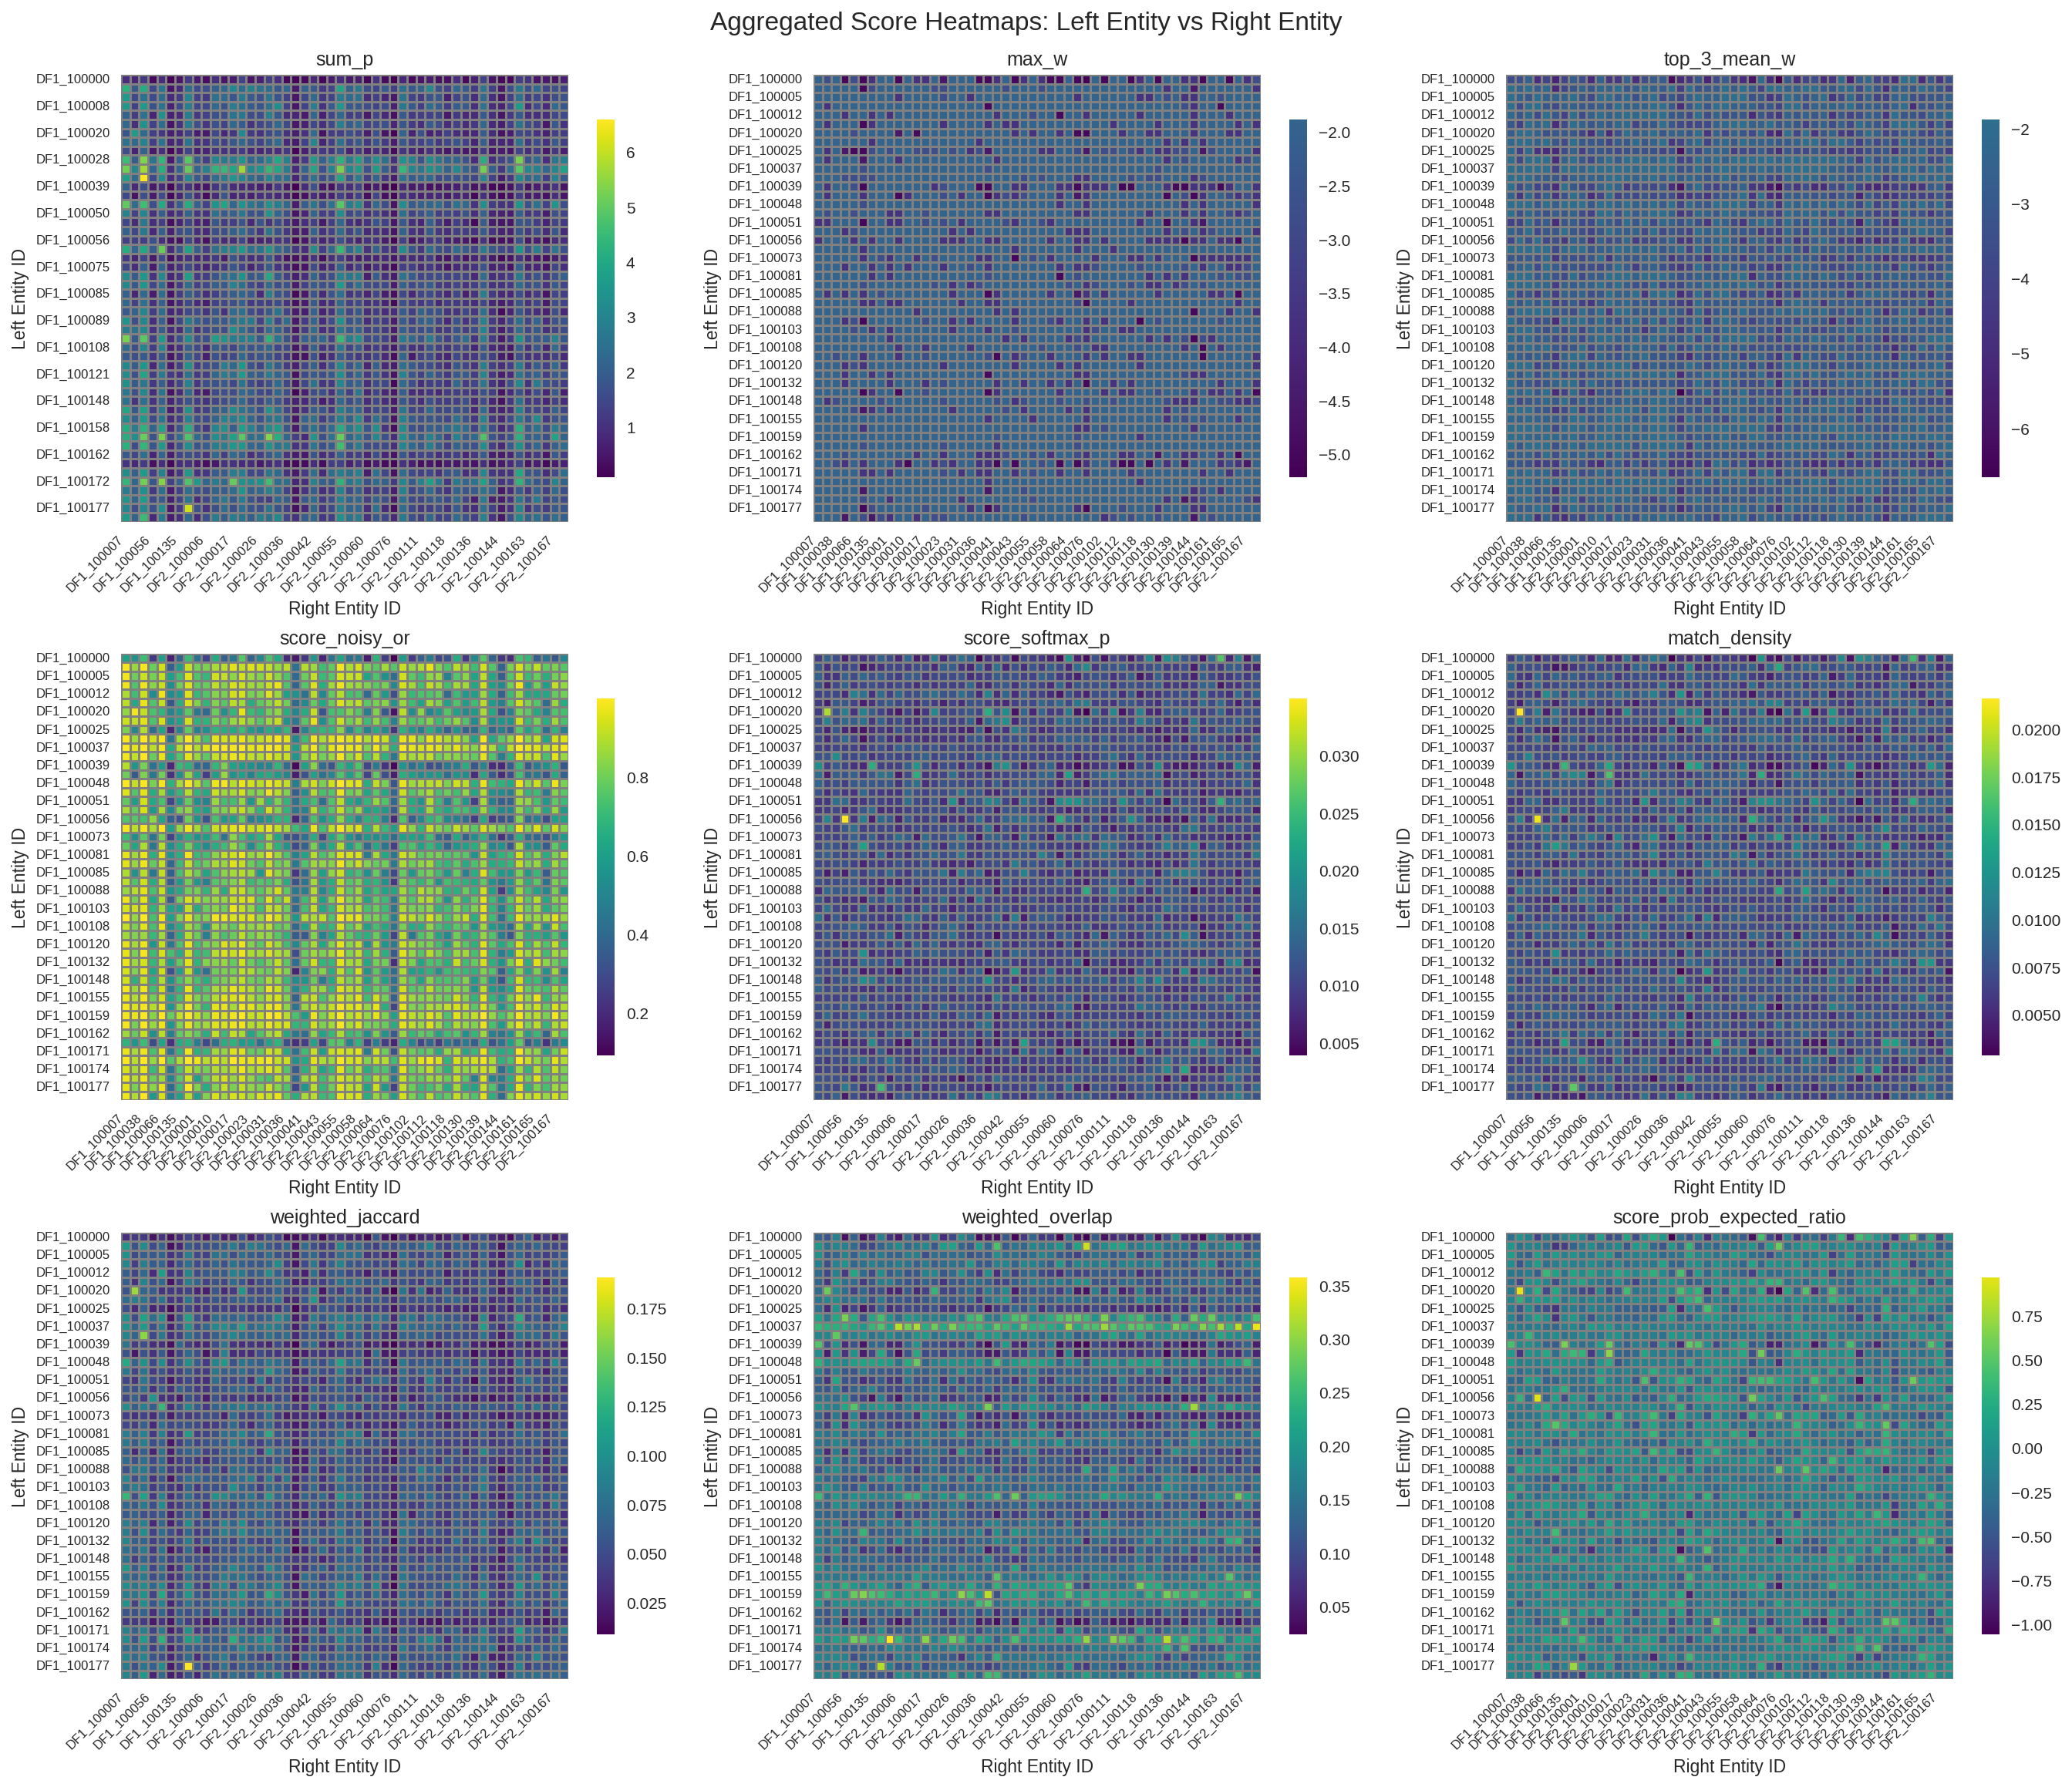

Figure saved to: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_low_card/aggregation_score_heatmaps.png


In [26]:
from helpers.visualization_helper import plot_aggregation_heatmaps, plot_threshold_evaluation

# Generate combined heatmap and precision-recall curves
plot_aggregation_heatmaps(
    aggregated_df=aggregated_with_metrics,  # or your aggregated dataframe
    score_columns=[
        'sum_p', 'max_w', 'top_3_mean_w', 
        'score_noisy_or', 'score_softmax_p',
        'match_density', 'weighted_jaccard', 
        'weighted_overlap', 'score_prob_expected_ratio'
    ],
    notebook_dir=NOTEBOOK_NAME
)

Computing entity-level ground truth for threshold evaluation...
Found 20 true entity pairs out of 10000 total pairs (0.20%)


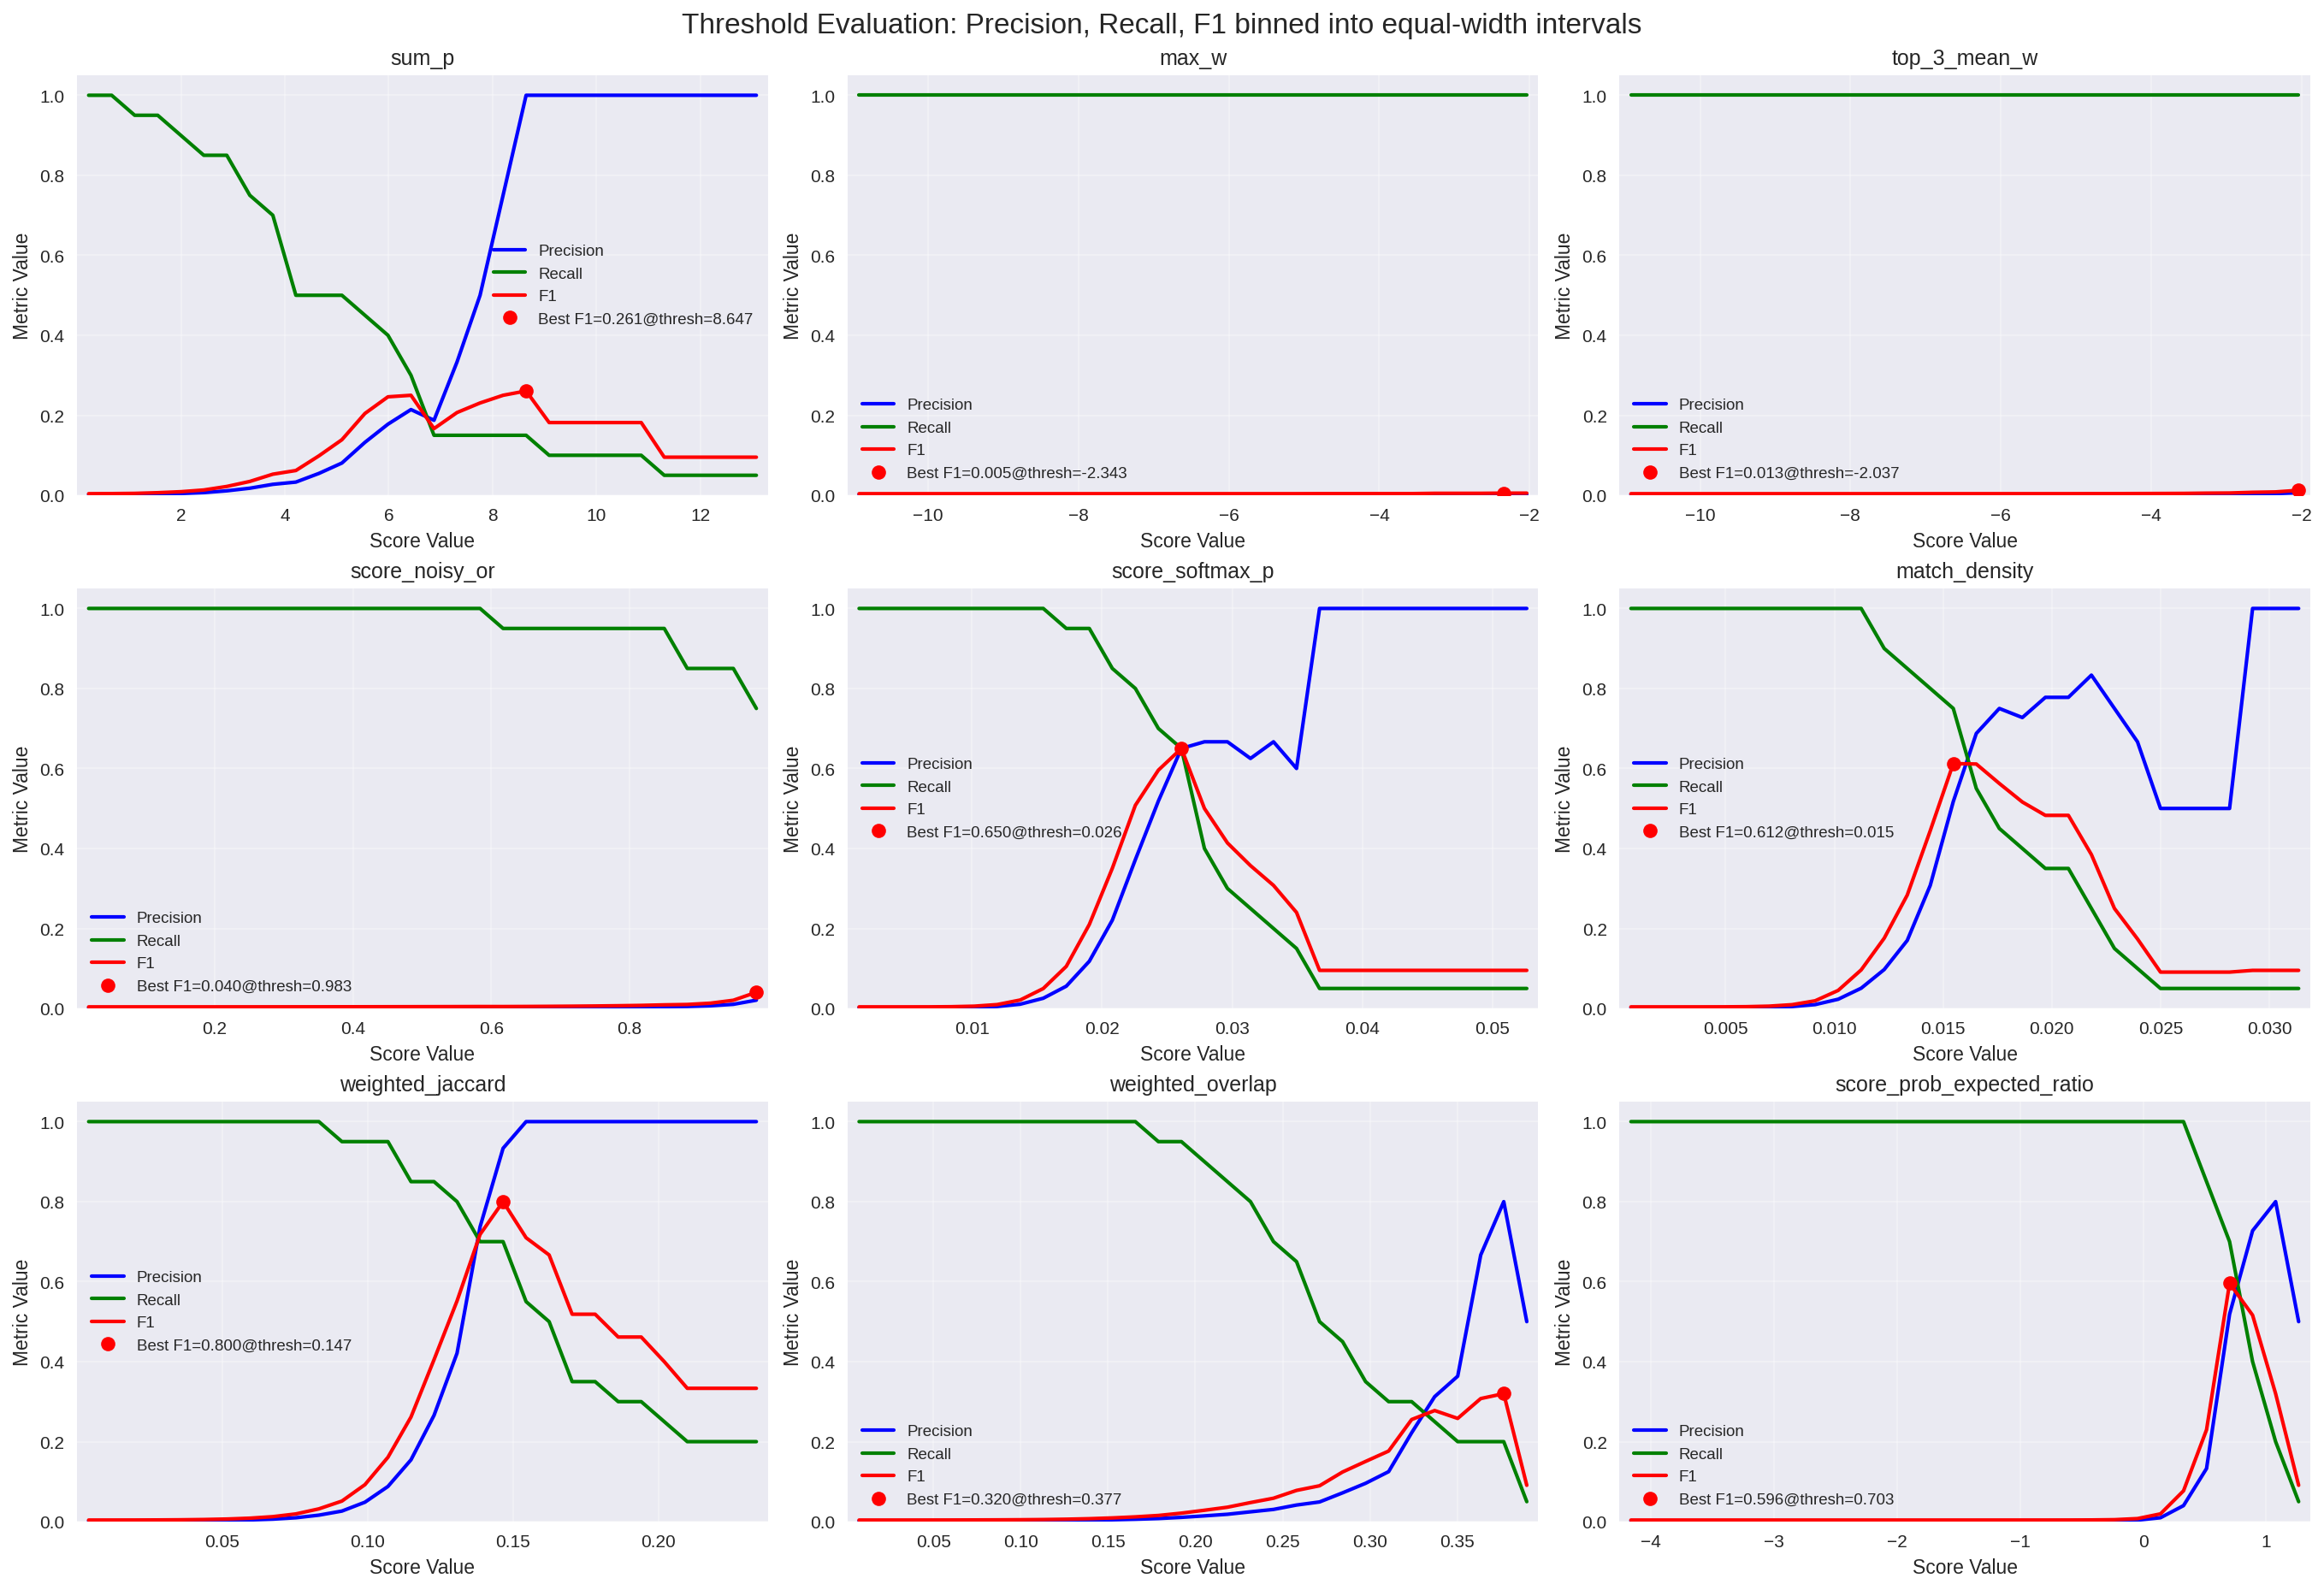

Figure saved to: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_low_card/threshold_evaluation_binned.png


In [27]:
plot_threshold_evaluation(
    aggregated_df=aggregated_with_metrics,
    df1=df1,
    df2=df2,
    score_columns=[
        'sum_p', 'max_w', 'top_3_mean_w', 
        'score_noisy_or', 'score_softmax_p',
        'match_density', 'weighted_jaccard', 
        'weighted_overlap', 'score_prob_expected_ratio'
    ],
    notebook_dir=NOTEBOOK_NAME,
    bins=30  # 30 bins as requeste
)

## We see that most of these aggregations are still rather poor - we attempt a second layer of FS.

In [71]:
from entity_resolution_aggregation import second_layer_splink_evaluation
from visualization_helper import plot_fellegi_sunter_weights

target_features = [
    "score_noisy_or",
    "score_softmax_p",
    "score_prob_expected_ratio",
    "top_3_mean_w"
]

# Run second-layer evaluation using all numeric features
second_layer_results, trained_params = second_layer_splink_evaluation(
    aggregated_with_metrics,  # Uses all numeric columns except IDs
    feature_columns=target_features,
    max_iter=100     # Increase for more stable estimates
)

print("Second-layer results shape:", second_layer_results.shape)
print("Available columns:", list(second_layer_results.columns))


Second-layer results shape: (10000, 14)
Available columns: ['local_source_id_l', 'local_source_id_r', 'sum_p', 'max_w', 'observed_edges', 'top_3_mean_w', 'score_noisy_or', 'score_softmax_p', 'match_density', 'weighted_jaccard', 'weighted_overlap', 'score_prob_expected_ratio', 'final_adjusted_prob', 'final_match_weight']


In [72]:
second_layer_results

,local_source_id_l,local_source_id_r,sum_p,max_w,observed_edges,top_3_mean_w,score_noisy_or,score_softmax_p,match_density,weighted_jaccard,weighted_overlap,score_prob_expected_ratio,final_adjusted_prob,final_match_weight
0,DF1_100000,DF1_100007,0.908990,-1.883754,100,-3.513597,0.611008,0.009677,0.006184,0.033553,0.129856,-0.282188,2.339446e-04,-12.879752
1,DF1_100000,DF1_100020,0.773497,-2.746997,59,-3.359008,0.547868,0.013603,0.008500,0.040231,0.110500,0.035973,1.000000e+00,52.776306
2,DF1_100000,DF1_100025,0.264131,-4.992022,55,-5.279770,0.233360,0.004837,0.003430,0.014892,0.037733,-0.871446,2.061154e-09,-41.115442
3,DF1_100000,DF1_100037,1.970464,-1.883754,176,-1.883754,0.873869,0.012145,0.008043,0.049225,0.281495,-0.019324,9.999380e-01,13.158758
4,DF1_100000,DF1_100038,1.194116,-1.883754,114,-2.459249,0.712697,0.011252,0.007108,0.040063,0.170588,-0.142892,9.963115e-01,7.258876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,DF1_100179,DF2_100164,2.246469,-1.883754,199,-2.171501,0.903392,0.012028,0.008139,0.068587,0.187206,-0.007375,9.999854e-01,15.245373
9996,DF1_100179,DF2_100165,1.386343,-3.665014,202,-4.107350,0.754075,0.006976,0.005023,0.041243,0.115529,-0.490066,2.061154e-09,-39.355068
9997,DF1_100179,DF2_100166,0.717390,-3.665014,121,-3.952762,0.516568,0.006047,0.004456,0.024499,0.102484,-0.609873,2.061154e-09,-41.115442
9998,DF1_100179,DF2_100167,1.751373,-3.665014,226,-3.665014,0.830643,0.007901,0.005439,0.049686,0.125098,-0.410486,2.061154e-09,-38.020296


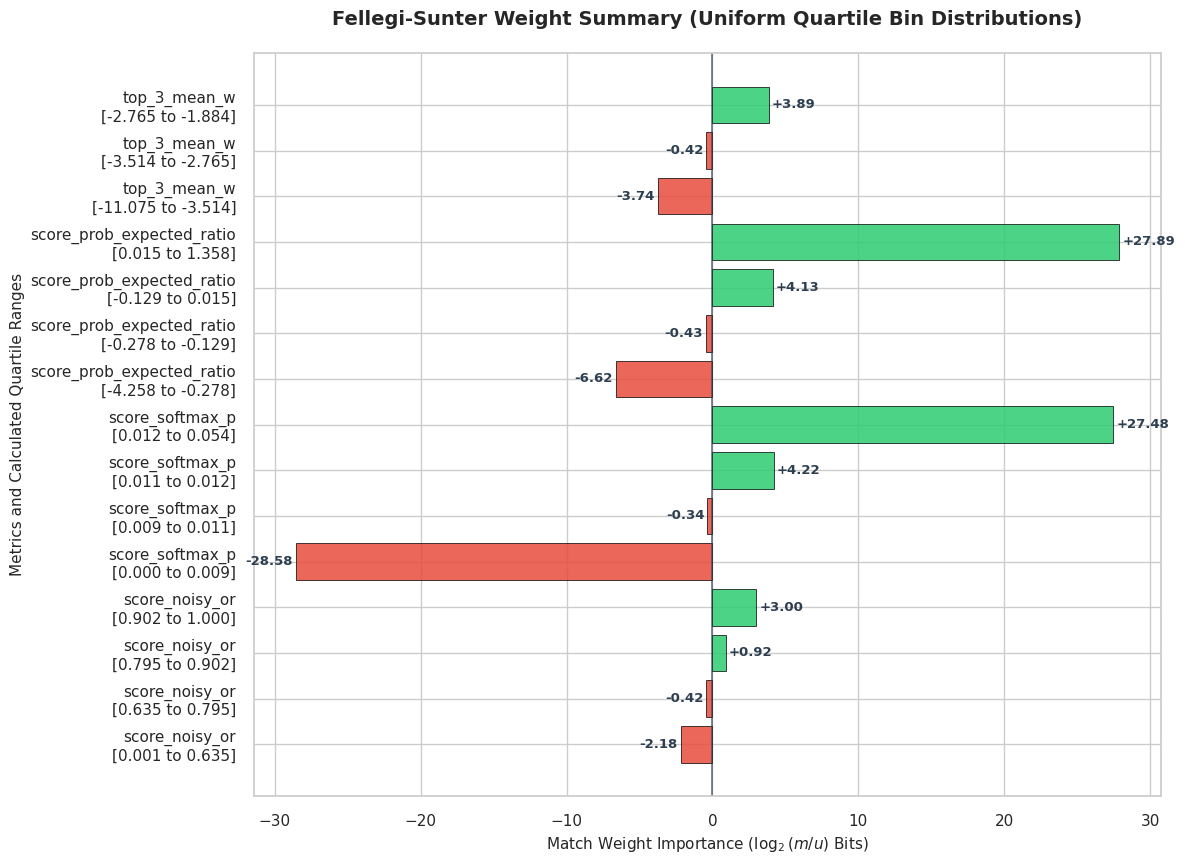

In [73]:
plot_fellegi_sunter_weights(trained_params)

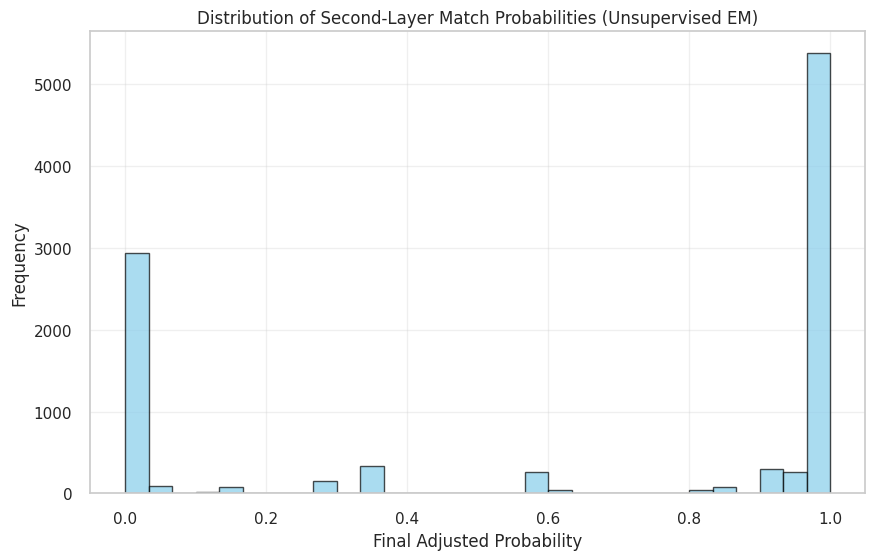

In [74]:
# Visualize second-layer results
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(second_layer_results['final_adjusted_prob'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_title('Distribution of Second-Layer Match Probabilities (Unsupervised EM)')
ax.set_xlabel('Final Adjusted Probability')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# In notebook: show_and_save_fig(fig, "splink_local_demo", "dist_second_layer_em")
plt.show()  # For script execution
# fig.savefig("dist_second_layer_em.png", dpi=150, bbox_inches='tight')


In [75]:
import seaborn as sns

def plot_threshold_evaluation_curves(scored_df):
    """Computes Precision, Recall, and F1-Score metrics against ground truth

    and visualizes them across a continuous probability threshold range.
    """
    # 1. Derive ground-truth binary targets (1 = Match, 0 = Non-Match)
    # True match condition: left ID and right ID refer to the exact same entity
    y_true = (
        scored_df["local_source_id_l"] == scored_df["local_source_id_r"]
    ).astype(int)

    # If your source IDs have systematic prefixes (e.g., DF1_100 vs DF2_100),
    # use this regex replacement fallback instead:
    # y_true = (scored_df['local_source_id_l'].str.replace(r'^DF\d+__', '', regex=True) ==
    #           scored_df['local_source_id_r'].str.replace(r'^DF\d+__', '', regex=True)).astype(int)

    total_true_matches = y_true.sum()
    if total_true_matches == 0:
        raise ValueError(
            "Zero true matches found in ground truth. Verify that matching pairs exist in the selection."
        )

    # 2. Sweep across 100 distinct probability thresholds from 0 to 1
    thresholds = np.linspace(0.001, 0.999, 100)
    precision_scores = []
    recall_scores = []
    f1_scores = []

    y_prob = scored_df["final_adjusted_prob"].values

    for t in thresholds:
        # Binary prediction vector for current threshold slice
        y_pred = (y_prob >= t).astype(int)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))

        # Handle edge-case divisions cleanly using standard defaults
        precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * (precision * recall) / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

    # Locate the mathematically optimal peak threshold
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_prec = precision_scores[best_idx]
    best_rec = recall_scores[best_idx]

    # 3. Generate Evaluation Chart Layout
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(11, 6.5))

    plt.plot(
        thresholds,
        precision_scores,
        label=f"Precision (Peak: {best_prec:.3f})",
        color="#2ecc71",
        linewidth=2.5,
    )
    plt.plot(
        thresholds,
        recall_scores,
        label=f"Recall (Peak: {best_rec:.3f})",
        color="#e74c3c",
        linewidth=2.5,
    )
    plt.plot(
        thresholds,
        f1_scores,
        label=f"F1-Score (Max: {best_f1:.3f})",
        color="#3498db",
        linewidth=3,
        linestyle="--",
    )

    # Draw vertical helper bar over the highest F1 confidence threshold
    plt.axvline(
        x=best_thresh,
        color="#2c3e50",
        linestyle=":",
        linewidth=1.5,
        alpha=0.8,
        label=f"Optimal Decision Cut ({best_thresh:.3f})",
    )

    # 4. Canvas Aesthetics and Annotations
    plt.title(
        "Fellegi-Sunter Model Multi-Threshold Performance Evaluation Curve\n"
        f"Ground Truth Matches Evaluated: {total_true_matches} Pairs",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel(
        "Probability Assignment Acceptance Threshold ($P_{match} \geq T$)",
        fontsize=11,
    )
    plt.ylabel("Evaluation Classification Metric Value Score", fontsize=11)
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)

    # Dynamic annotation box positioning showing the optimal parameters
    plt.text(
        x=0.05,
        y=0.15,
        s=f"Optimal Operational Strategy:\n"
        f"▪ Threshold: {best_thresh:.3f}\n"
        f"▪ Max F1: {best_f1:.4f}\n"
        f"▪ Precision: {best_prec:.4f}\n"
        f"▪ Recall: {best_rec:.4f}",
        bbox=dict(
            boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor="#dcdde1"
        ),
        fontsize=10.5,
        fontweight="semibold",
        color="#2c3e50",
    )

    plt.legend(loc="upper right", frameon=True, facecolor="white", shadow=True)
    plt.tight_layout()
    plt.show()

    return {
        "threshold": best_thresh,
        "f1": best_f1,
        "precision": best_prec,
        "recall": best_rec,
    }


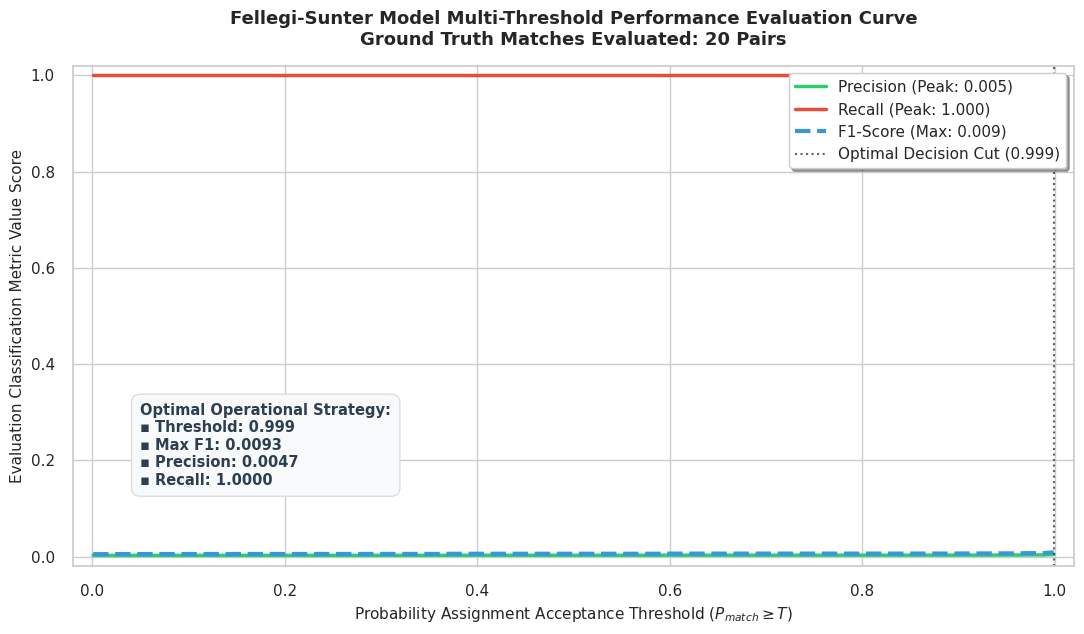

Deploy model at probability cutoff: 0.9990


: 

In [ ]:
# Pass your scored data directly into the evaluation visualizer
performance_metrics = plot_threshold_evaluation_curves(second_layer_results)

# Print your structural classification split rules
print(f"Deploy model at probability cutoff: {performance_metrics['threshold']:.4f}")


In this specific case - it seems that a second layer of fellegi-sunter might still prove fruitless - 
however, this is still mostly attributed to having a largely noisy dataset with poor discriminatory power.